In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

real_file = "Cardiovascular_Disease_Dataset.csv"
synthetic_file = "final_dataset_2M.csv"

data = pd.read_csv(real_file)
synthetic_data = pd.read_csv(synthetic_file)

print("Real Data Shape:", data.shape)
print("Synthetic Data Shape:", synthetic_data.shape)

Real Data Shape: (1000, 14)
Synthetic Data Shape: (2001000, 14)


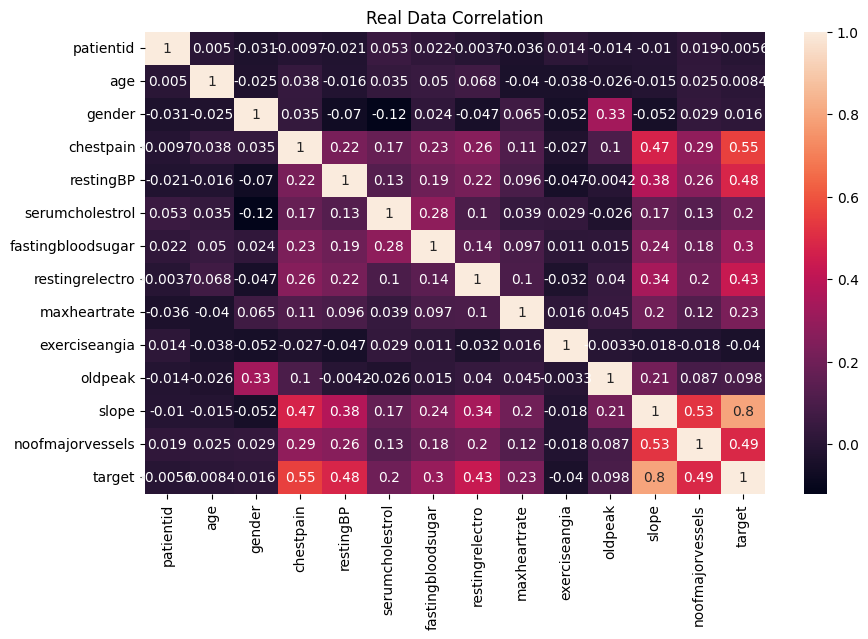

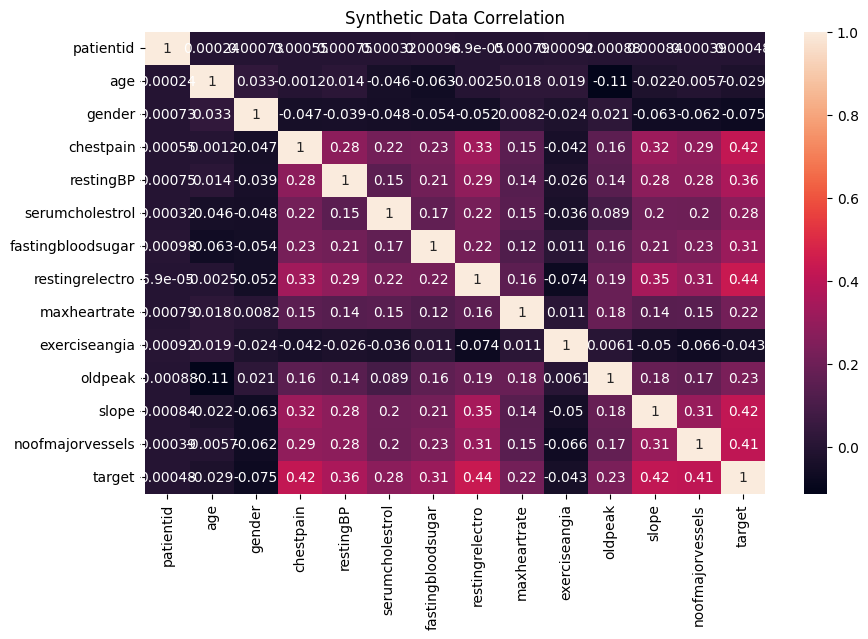

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True)
plt.title("Real Data Correlation")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(synthetic_data.corr(), annot=True)
plt.title("Synthetic Data Correlation")
plt.show()

In [8]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=data)

In [9]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

quality_report

Generating report ...

(1/2) Evaluating Column Shapes: |█████████████████████████████████████████████████████| 14/14 [00:06<00:00,  2.11it/s]|
Column Shapes Score: 87.56%

(2/2) Evaluating Column Pair Trends: |████████████████████████████████████████████████| 91/91 [00:14<00:00,  6.17it/s]|
Column Pair Trends Score: 78.27%

Overall Score (Average): 82.92%



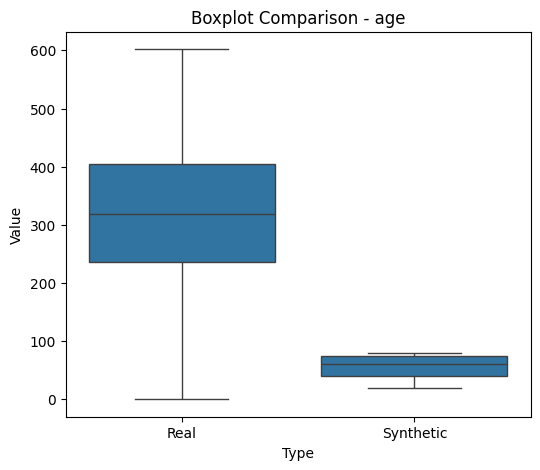

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# create proper comparison dataframe
real_sample = data[""]
synthetic_sample = synthetic_data["age"].sample(n=len(real_sample), random_state=42)

df_plot = pd.DataFrame({
    "Value": pd.concat([real_sample, synthetic_sample], ignore_index=True),
    "Type": ["Real"] * len(real_sample) + ["Synthetic"] * len(real_sample)
})

plt.figure(figsize=(6,5))

sns.boxplot(x="Type", y="Value", data=df_plot)

plt.title("Boxplot Comparison - age")
plt.show()

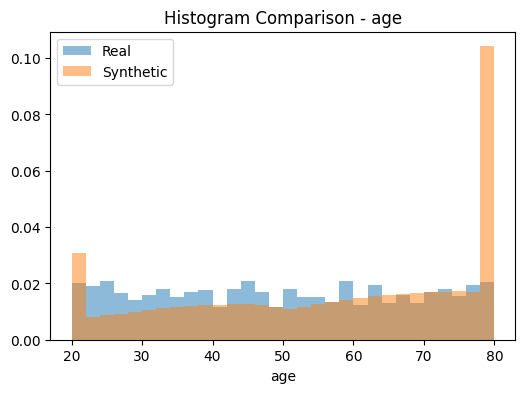

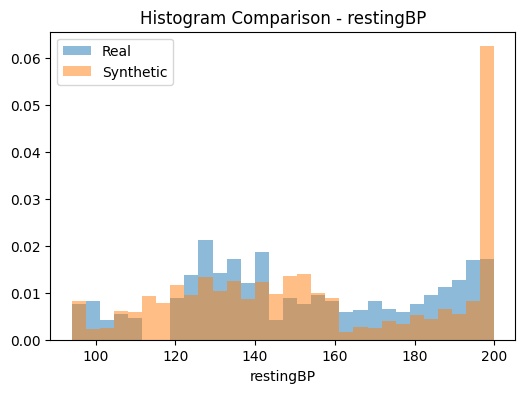

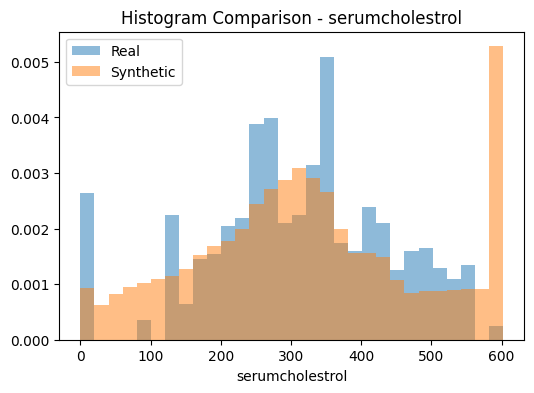

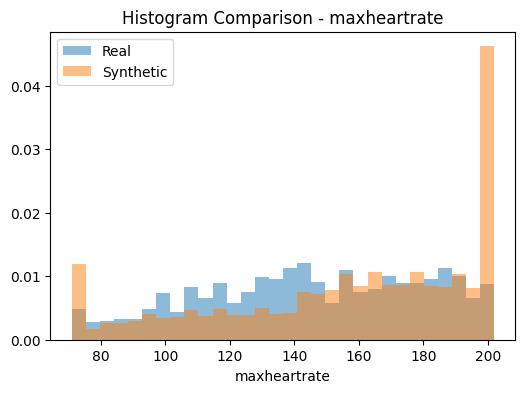

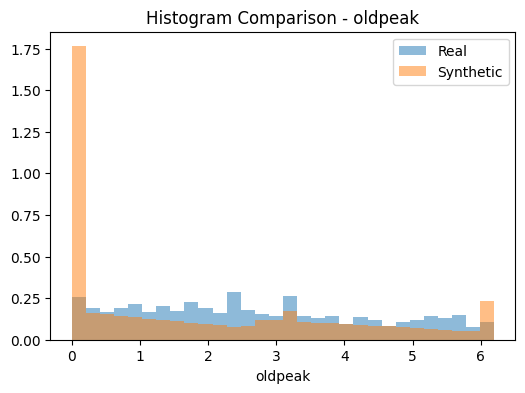

In [31]:
import matplotlib.pyplot as plt

columns = ["age", "restingBP", "serumcholestrol", "maxheartrate", "oldpeak"]
for column in columns:
    plt.figure(figsize=(6,4))

    plt.hist(data[column], bins=30, alpha=0.5, label="Real", density=True)
    plt.hist(synthetic_data[column], bins=30, alpha=0.5, label="Synthetic", density=True)

    plt.legend()
    plt.title(f"Histogram Comparison - {column}")
    plt.xlabel(column)

    plt.show()

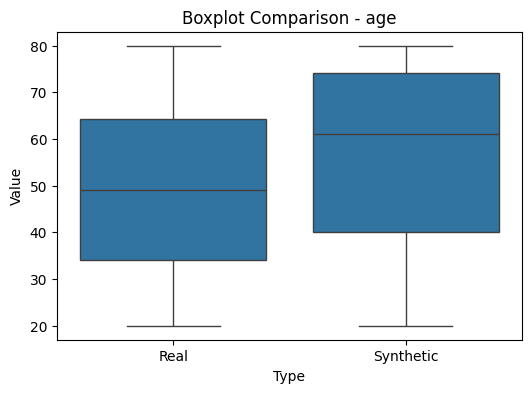

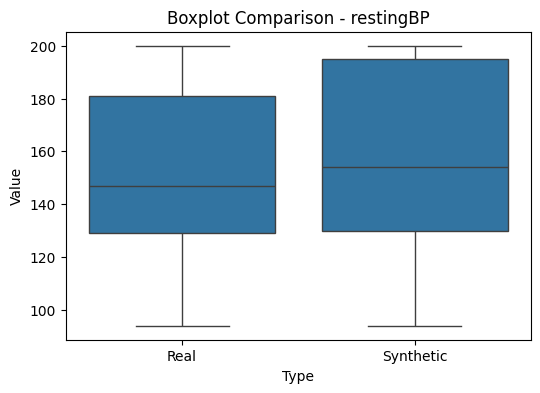

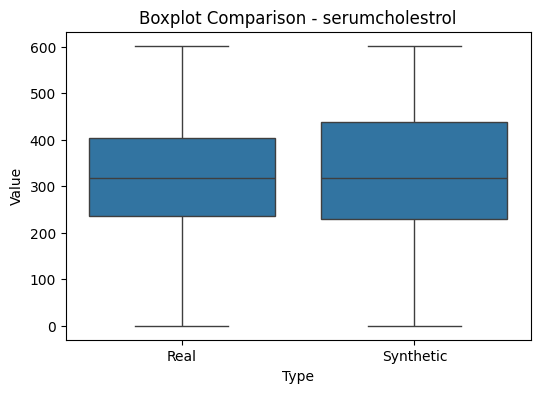

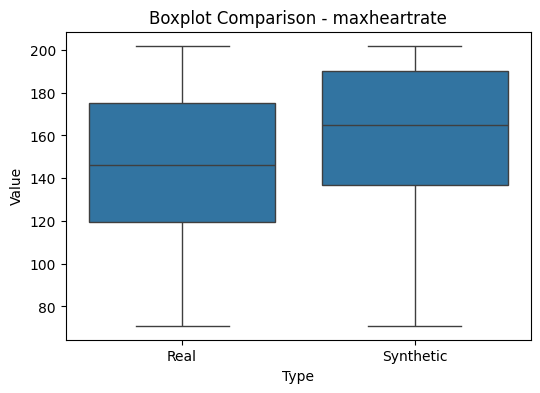

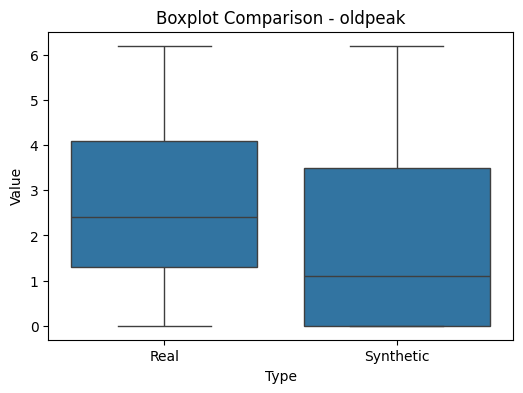

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# select only numeric columns
columns = ["age", "restingBP", "serumcholestrol", "maxheartrate", "oldpeak"]

for column in columns:
    
    # sample synthetic to match real size
    synthetic_sample = synthetic_data[column].sample(n=len(data), random_state=42)

    # create combined dataframe
    df_plot = pd.DataFrame({
        "Value": pd.concat([data[column], synthetic_sample], ignore_index=True),
        "Type": ["Real"] * len(data) + ["Synthetic"] * len(data)
    })

    plt.figure(figsize=(6,4))
    sns.boxplot(x="Type", y="Value", data=df_plot)
    plt.title(f"Boxplot Comparison - {column}")
    plt.show()

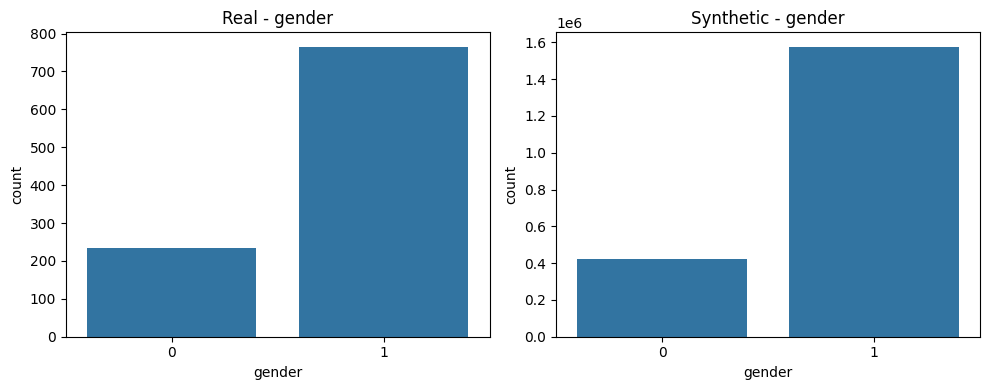

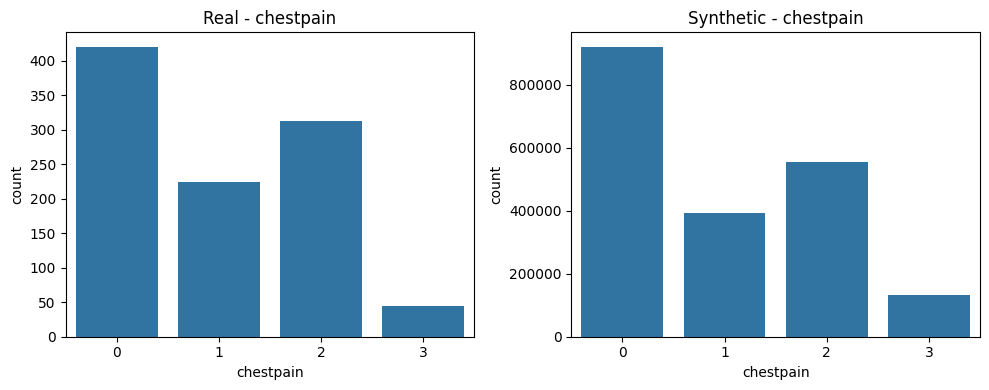

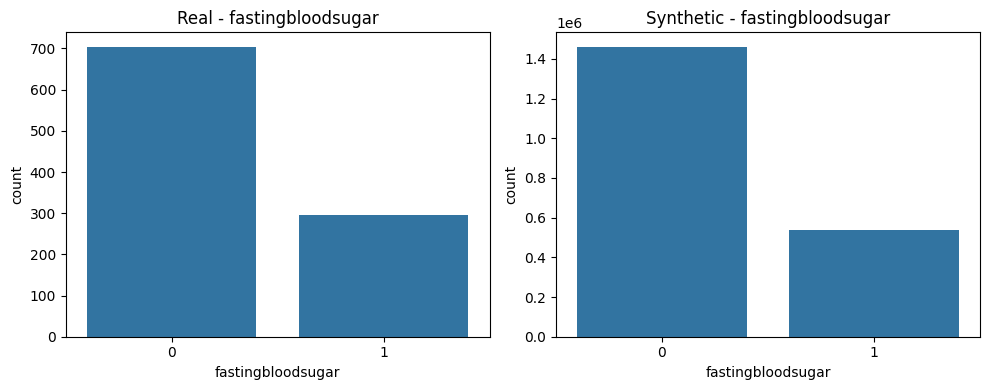

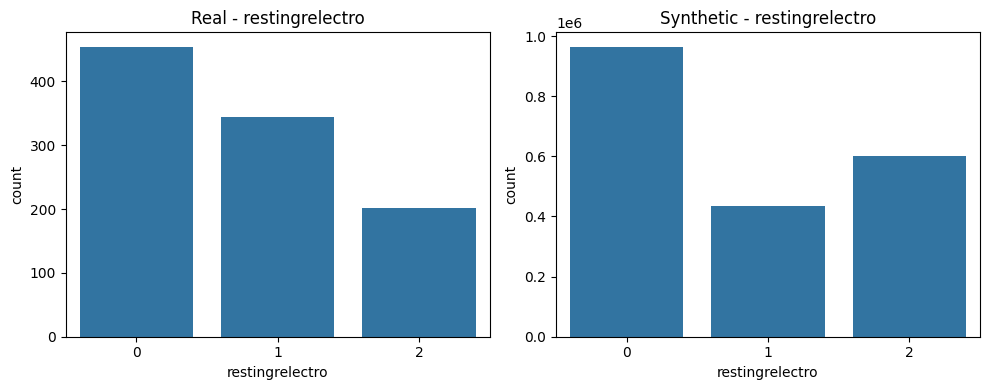

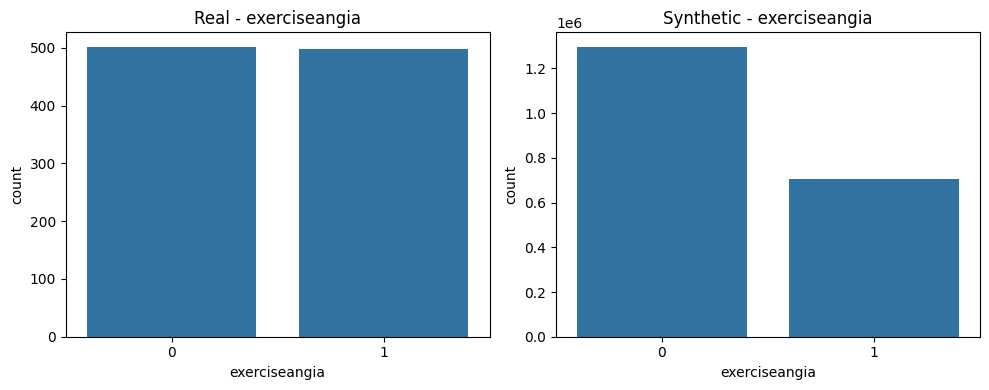

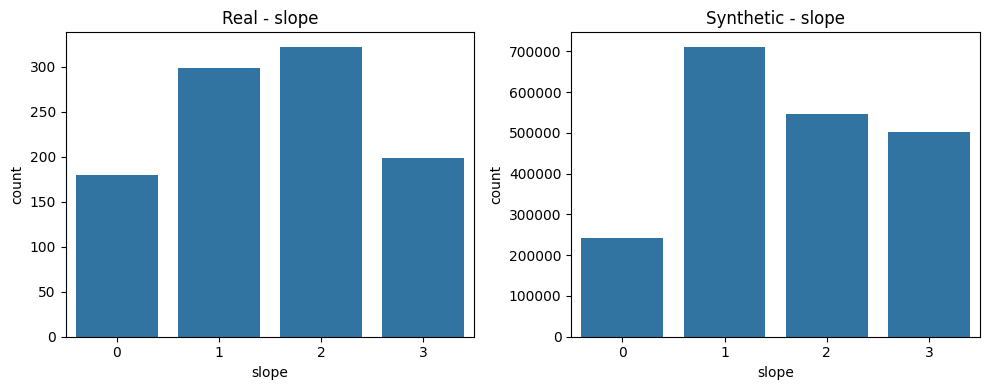

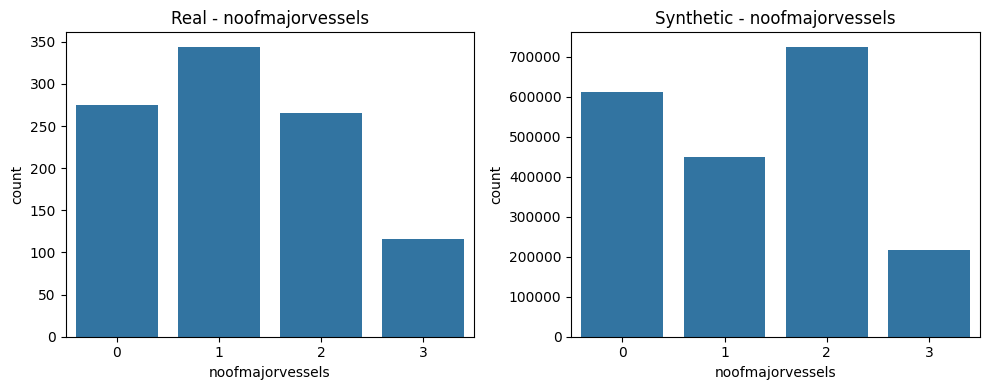

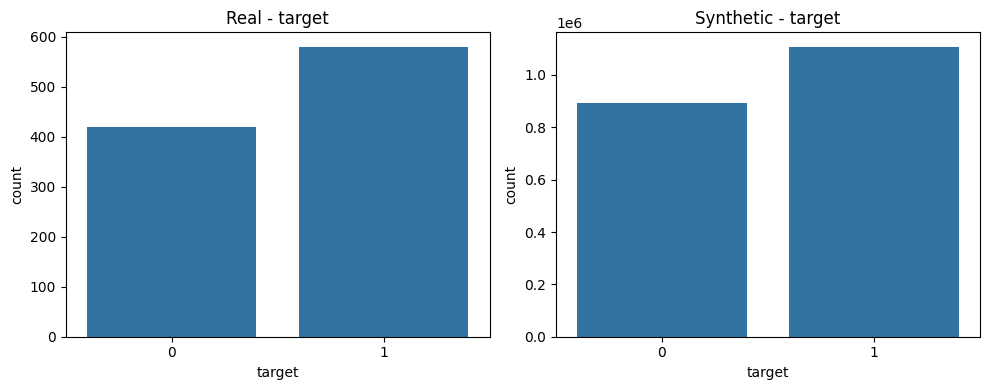

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# list of categorical columns
cat_columns = [
    "gender", "chestpain", "fastingbloodsugar",
    "restingrelectro", "exerciseangia",
    "slope", "noofmajorvessels", "target"
]

for column in cat_columns:
    plt.figure(figsize=(10,4))

    # Real data
    plt.subplot(1,2,1)
    sns.countplot(x=data[column])
    plt.title(f"Real - {column}")

    # Synthetic data
    plt.subplot(1,2,2)
    sns.countplot(x=synthetic_data[column])
    plt.title(f"Synthetic - {column}")

    plt.tight_layout()
    plt.show()